## Student Performance Indicator


### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns

In [2]:
df = pd.read_csv("StudentsPerformance.csv")

In [3]:
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

In [5]:
df.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [6]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:

df.select_dtypes(include='object').nunique()

gender                         2
race/ethnicity                 5
parental level of education    6
lunch                          2
test preparation course        2
dtype: int64

In [9]:
df[['math score', 'reading score', 'writing score']].describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [10]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race/ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test preparation course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [12]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math score', 'reading score', 'writing score']

We have 5 categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


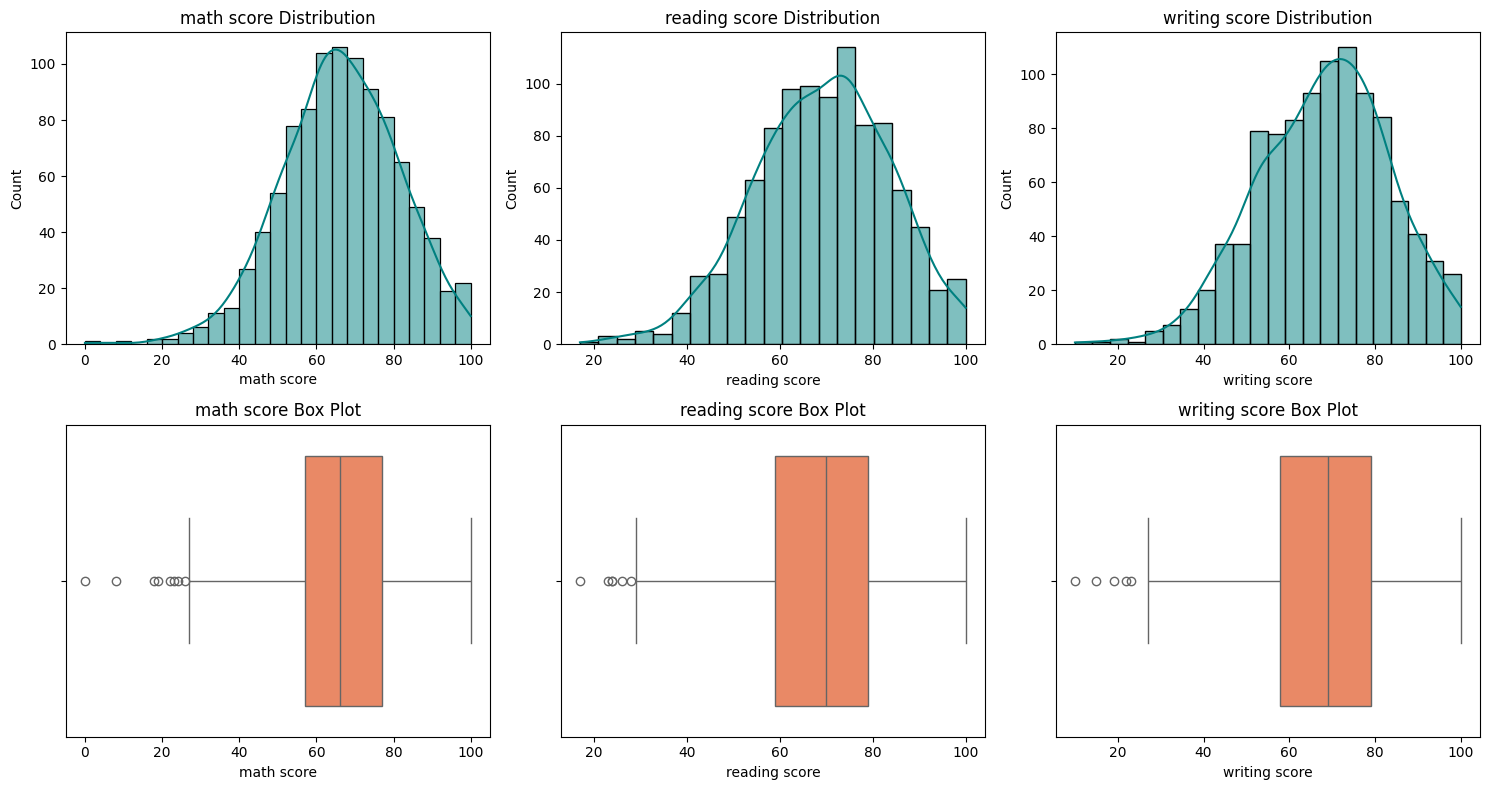

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
numeric_cols = ['math score', 'reading score', 'writing score']

for i, col in enumerate(numeric_cols):
    # Distribution shape
    sns.histplot(df[col], kde=True, ax=axes[0, i], color='teal')
    axes[0, i].set_title(f'{col} Distribution')
    
    # Outliers
    sns.boxplot(x=df[col], ax=axes[1, i], color='coral')
    axes[1, i].set_title(f'{col} Box Plot')

plt.tight_layout()
plt.show()

/var/folders/0w/3bg7m45d45q3c1pn32w6zg8m0000gn/T/ipykernel_13660/3220921680.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='pastel')
/var/folders/0w/3bg7m45d45q3c1pn32w6zg8m0000gn/T/ipykernel_13660/3220921680.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='pastel')
/var/folders/0w/3bg7m45d45q3c1pn32w6zg8m0000gn/T/ipykernel_13660/3220921680.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='pastel')
/var/folders/0w/

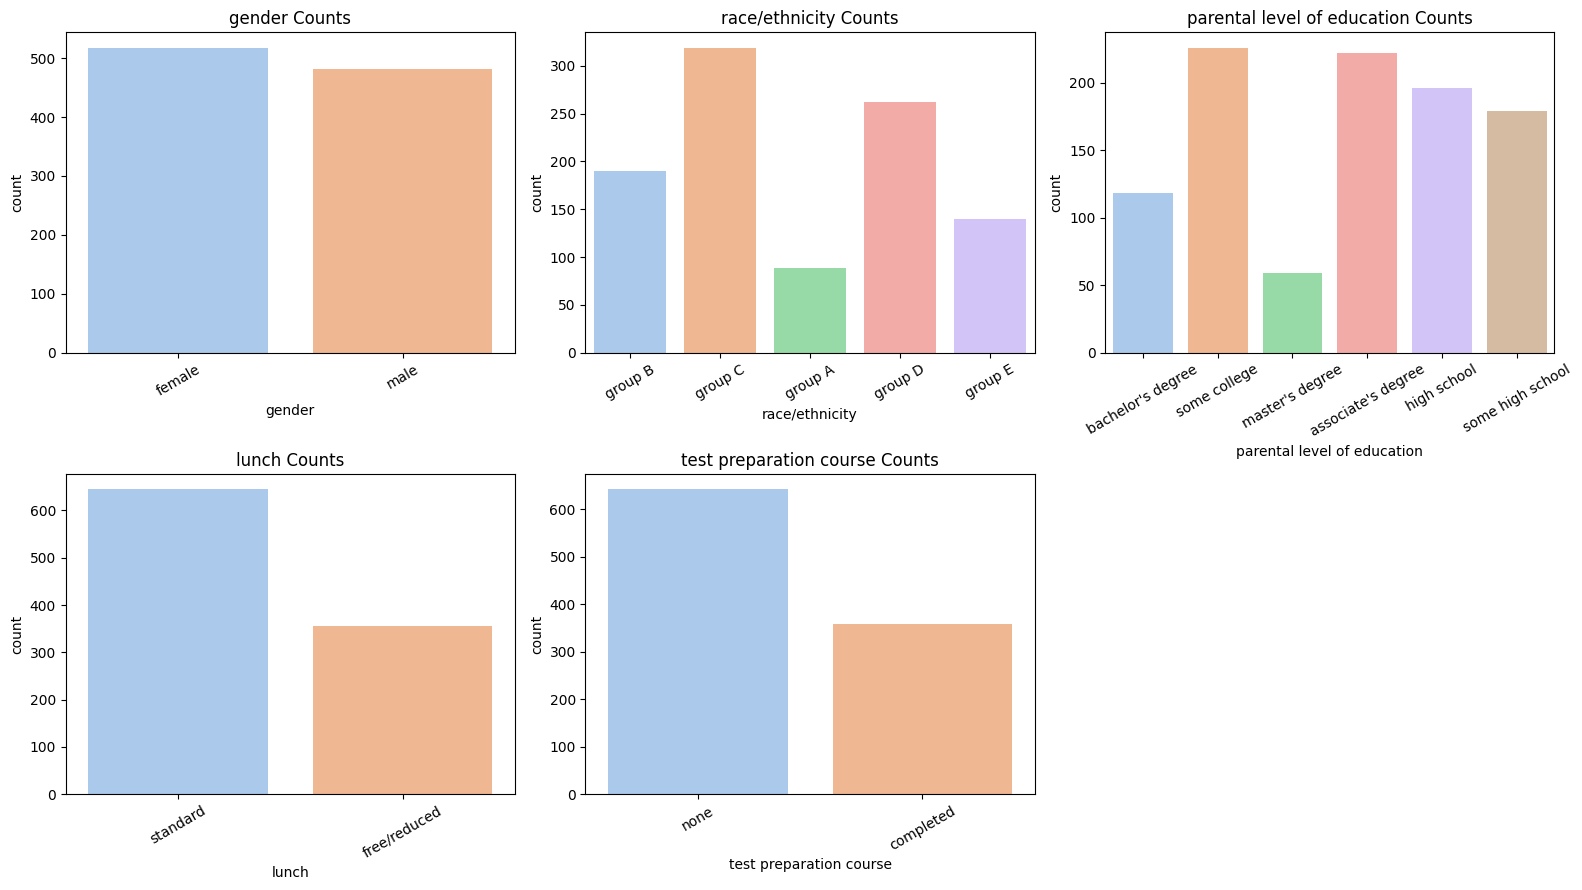

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the categorical columns explicitly
cat_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

# 2. Create the subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='pastel')
    axes[i].set_title(f'{col} Counts')
    axes[i].tick_params(axis='x', rotation=30)

fig.delaxes(axes[5])  # Remove the empty 6th subplot
plt.tight_layout()
plt.show()

               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


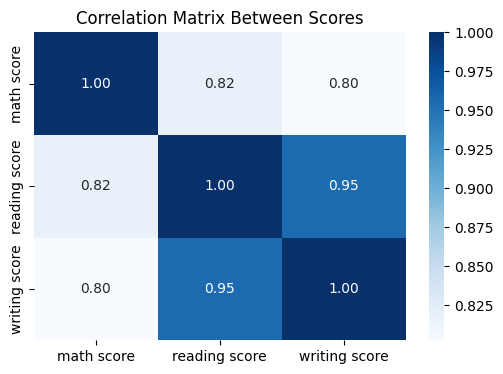

In [15]:
# 1. Correlation Matrix
corr = df[['math score', 'reading score', 'writing score']].corr()
print(corr)

# 2. Visualize with a Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix Between Scores')
plt.show()

In [16]:
df.groupby('test preparation course')[['math score', 'reading score', 'writing score']].mean().round(2)

,math score,reading score,writing score
test preparation course,,,
completed,69.70,73.89,74.42
none,64.08,66.53,64.50


In [17]:
df.groupby('gender')[['math score', 'reading score', 'writing score']].mean().round()

,math score,reading score,writing score
gender,,,
female,64.0,73.0,72.0
male,69.0,65.0,63.0


In [18]:
df.groupby('lunch')[['math score', 'reading score', 'writing score']].mean().round(2)

,math score,reading score,writing score
lunch,,,
free/reduced,58.92,64.65,63.02
standard,70.03,71.65,70.82


In [19]:
# 1. Grouped averages sorted by mean math score
parental_summary = df.groupby('parental level of education')[['math score', 'reading score', 'writing score']].mean()

# Sort logically by educational tier
education_order = [
    'some high school', 
    'high school', 
    'some college', 
    "associate's degree", 
    "bachelor's degree", 
    "master's degree"
]
parental_summary = parental_summary.reindex(education_order).round(2)
print(parental_summary)

                             math score  reading score  writing score
parental level of education                                          
some high school                  63.50          66.94          64.89
high school                       62.14          64.70          62.45
some college                      67.13          69.46          68.84
associate's degree                67.88          70.93          69.90
bachelor's degree                 69.39          73.00          73.38
master's degree                   69.75          75.37          75.68


In [20]:
# 1. Total and Average Score
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']
df['average_score'] = (df['total_score'] / 3).round(2)

# 2. Pass/Fail Status per subject (passing mark = 40)
passing_mark = 40
df['math_pass'] = df['math score'] >= passing_mark
df['reading_pass'] = df['reading score'] >= passing_mark
df['writing_pass'] = df['writing score'] >= passing_mark

# 3. Overall Pass (must pass all 3 subjects)
df['overall_pass'] = df['math_pass'] & df['reading_pass'] & df['writing_pass']

# View pass rates
print(df[['math_pass', 'reading_pass', 'writing_pass', 'overall_pass']].mean() * 100)

math_pass       96.0
reading_pass    97.4
writing_pass    96.8
overall_pass    94.9
dtype: float64


In [21]:
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score,math_pass,reading_pass,writing_pass,overall_pass
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.67,True,True,True,True
1,female,group C,some college,standard,completed,69,90,88,247,82.33,True,True,True,True
2,female,group B,master's degree,standard,none,90,95,93,278,92.67,True,True,True,True
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.33,True,True,True,True
4,male,group C,some college,standard,none,76,78,75,229,76.33,True,True,True,True


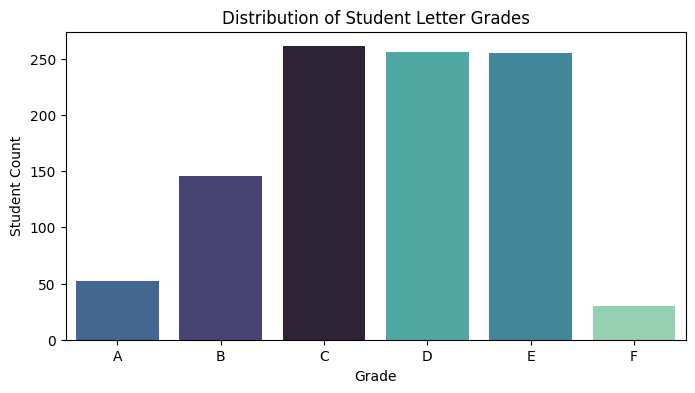

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compute average score
df['average_score'] = ((df['math score'] + df['reading score'] + df['writing score']) / 3).round(2)

# 2. Assign grade function
def assign_grade(score):
    if score >= 90:
        return 'A'
    elif score >= 80:
        return 'B'
    elif score >= 70:
        return 'C'
    elif score >= 60:
        return 'D'
    elif score >= 40:
        return 'E'
    else:
        return 'F'

# 3. Create the 'grade' column
df['grade'] = df['average_score'].apply(assign_grade)

# 4. Plot the grade distribution
grade_order = ['A', 'B', 'C', 'D', 'E', 'F']

plt.figure(figsize=(8, 4))
sns.countplot(
    data=df, 
    x='grade', 
    order=grade_order, 
    hue='grade', 
    palette='mako', 
    legend=False
)
plt.title('Distribution of Student Letter Grades')
plt.xlabel('Grade')
plt.ylabel('Student Count')
plt.show()